# Fitting Simple Linear Statistical Models
## Step 2 — Building a model one variable at a time

In Step 1 we turned 52,563 billed lines into **3,361 medical events**, each with a total cost. Now we start explaining that cost.

**The method.** We add predictors **one at a time**, and each addition has to earn its place. At every step we ask two separate questions:

| Question | Tool | What it tells us |
|---|---|---|
| Is this effect distinguishable from zero? | **$t$-test** | *statistical* significance |
| Does the model actually explain more? | **$R^2$** | *practical* importance |

These two questions are not the same, and a central lesson of this notebook is what happens when they disagree.

**Two restrictions we impose on ourselves for now.**

- Only **quantitative** predictors — no categorical variables, no dummies.
- Only **linear** forms — no logarithms, no squared terms, no interactions.

Both restrictions will be lifted in later notebooks. 

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["figure.dpi"] = 110

---
## 2. Loading the medical events

We pick up the file saved at the end of Step 1. If it is not present — for instance if you are running this notebook on a fresh machine — the cell rebuilds it from the original source, so this notebook is self-contained either way.

In [2]:
URL = ("https://raw.githubusercontent.com/thousandoaks/Python4DS-I/"
       "main/datasets/HealthcareDataset_PublicRelease.csv")

try:
    events = pd.read_csv("medical_events.csv", parse_dates=["StartDate", "EndDate", "BirthDate"])
    print("loaded medical_events.csv from Step 1")
except FileNotFoundError:
    print("medical_events.csv not found — rebuilding from source")
    lines = pd.read_csv(URL, parse_dates=["StartDate", "EndDate", "BirthDate"])
    lines["LOS"] = (lines.EndDate - lines.StartDate).dt.days
    events = (lines.groupby("MedicalClaim")
              .agg(MemberID=("MemberID", "first"),
                   TotalCost=("TotalExpenses", "sum"),
                   NumLines=("Id", "size"),
                   NumRevCodes=("RevenueCode", "nunique"),
                   StartDate=("StartDate", "first"),
                   EndDate=("EndDate", "first"),
                   LOS=("LOS", "first"),
                   TypeFlag=("TypeFlag", "first"),
                   HospitalName=("HospitalName", "first"),
                   HospitalType=("HospitalType", "first"),
                   Diagnosis=("PrincipalDiagnosis", "first"),
                   DiagnosisDesc=("PrincipalDiagnosisDesc", "first"),
                   BirthDate=("BirthDate", "first"))
              .reset_index())

print(f"{len(events):,} medical events x {events.shape[1]} columns")
events.head()

medical_events.csv not found — rebuilding from source
3,361 medical events x 14 columns


,MedicalClaim,MemberID,TotalCost,NumLines,NumRevCodes,StartDate,EndDate,LOS,TypeFlag,HospitalName,HospitalType,Diagnosis,DiagnosisDesc,BirthDate
0,0012a8eb3c2be5f5,2c403f93,"4,668.692",4,4,2020-11-18,2020-11-18,0,ER,ae2f2d9e,HOSPITAL,S86.011A,Strain of right Achilles,1956-08-25
1,002fd7d73d8060f1,3eae7881,"53,501.259",24,24,2020-07-17,2020-07-23,6,INP,cf2a3695,HOSPITAL,G50.0,Trigeminal neuralgia,1945-09-05
2,003886fc8ec986d4,7910c083,"17,115.714",18,13,2020-02-26,2020-02-26,0,ER,b592f5ae,HOSPITAL,J20.9,Acute bronchitis unspecif,1955-10-10
3,004fa1cd47f65193,9b794cb5,"3,672.361",9,6,2020-09-06,2020-09-06,0,ER,4d103af0,HOSPITAL,B02.9,Zoster without complicati,1951-09-27
4,005edafb00d0f6eb,f48d86f4,"2,548.700",3,3,2020-03-06,2020-03-06,0,ER,a9bf1474,HOSPITAL,M79.672,Pain in left foot,1946-11-03


---
## 3. Building the candidate predictors

Our response is `TotalCost`. The events table already contains three quantitative columns — `LOS`, `NumLines` and `NumRevCodes` — and we can derive four more from what is there.

| Candidate | Definition | Why it might explain cost |
|---|---|---|
| `LOS` | discharge − admission, in days | longer stays consume more of everything |
| `NumRevCodes` | distinct revenue codes used | *variety* of services: a proxy for case complexity |
| `NumLines` | number of billed lines | sheer volume of billed activity |
| `Age` | patient's age at admission | older patients may need more care |
| `DiagnosisFreq` | how many events in the year share this diagnosis | rare conditions may be costlier to treat |
| `HospitalVolume` | how many events this hospital handled | large centres may treat differently, or price differently |
| `PatientEvents` | how many events this patient had in the year | frequent attenders may be sicker |
| `AdmissionMonth` | month of admission, 1–12 | is there a seasonal pattern? |

The last three are worth a word. They are **contextual** variables: they describe not the event itself but the situation around it. They are all legitimately quantitative, so under our rules they are eligible — but as we will see, eligibility is not the same as usefulness.

In [3]:
events["Age"] = ((events.StartDate - events.BirthDate).dt.days / 365.25).round(1)
events["DiagnosisFreq"]  = events.groupby("Diagnosis").Diagnosis.transform("size")
events["HospitalVolume"] = events.groupby("HospitalName").HospitalName.transform("size")
events["PatientEvents"]  = events.groupby("MemberID").MemberID.transform("size")
events["AdmissionMonth"] = events.StartDate.dt.month

candidates = ["LOS", "NumRevCodes", "NumLines", "Age",
              "DiagnosisFreq", "HospitalVolume", "PatientEvents", "AdmissionMonth"]

events[candidates].describe().T[["mean", "50%", "min", "max"]]

,mean,50%,min,max
LOS,2.608,1.000,0.000,129.000
NumRevCodes,12.346,11.000,1.000,43.000
NumLines,15.639,15.000,1.000,127.000
Age,71.069,72.600,20.500,99.700
DiagnosisFreq,19.431,7.000,1.000,105.000
HospitalVolume,302.643,253.000,1.000,738.000
PatientEvents,3.900,2.000,1.000,35.000
AdmissionMonth,6.223,6.000,1.000,12.000


### 3.1 Screening by correlation

Before fitting anything, look at how each candidate moves with cost on its own.

In [4]:
screen = (events[candidates + ["TotalCost"]].corr()["TotalCost"]
          .drop("TotalCost").sort_values(key=abs, ascending=False))
screen.to_frame("correlation with TotalCost")

,correlation with TotalCost
LOS,0.786
NumRevCodes,0.698
NumLines,0.431
Age,0.100
DiagnosisFreq,0.056
PatientEvents,-0.054
AdmissionMonth,0.034
HospitalVolume,0.032


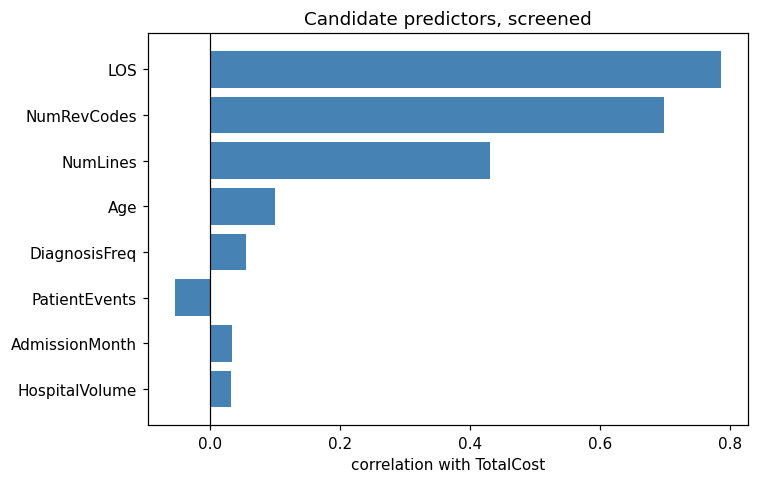

In [5]:
plt.barh(screen.index[::-1], screen.values[::-1], color="steelblue")
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("correlation with TotalCost")
plt.title("Candidate predictors, screened")
plt.tight_layout(); plt.show()

Two candidates stand out: `LOS` at 0.79 and `NumRevCodes` at 0.70. `NumLines` follows at 0.43. The remaining four are all below 0.11 in absolute value — barely distinguishable from noise by eye.

**But treat this screen as a starting point, not a verdict.** A correlation looks at each variable in isolation; a regression looks at what a variable adds *given the others*. We will see both a variable that is strong alone and useless in company, and variables that are weak alone yet statistically significant in company.

---
## 4. Model 1 — the strongest single predictor

$$\text{TotalCost} = \beta_0 + \beta_1 \cdot \text{LOS} + \varepsilon$$

Always plot before fitting.

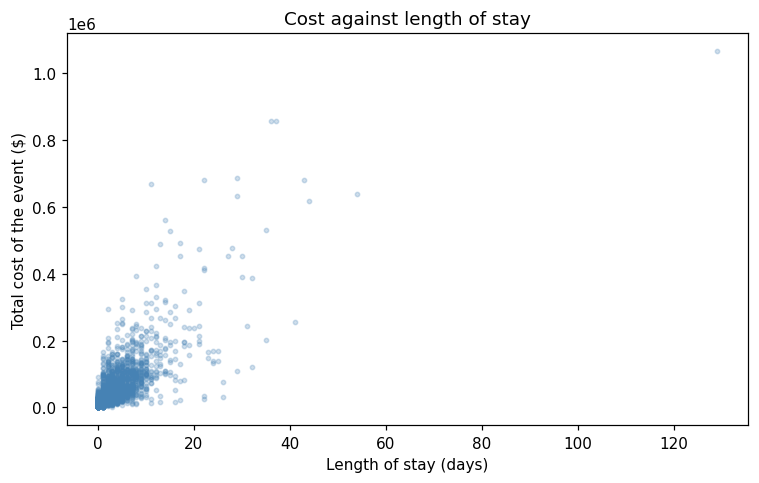

In [6]:
plt.scatter(events.LOS, events.TotalCost, s=8, alpha=0.25, color="steelblue")
plt.xlabel("Length of stay (days)"); plt.ylabel("Total cost of the event ($)")
plt.title("Cost against length of stay")
plt.tight_layout(); plt.show()

In [7]:
m1 = smf.ols("TotalCost ~ LOS", data=events).fit()
print(m1.summary().tables[1])
print(f"R-squared: {m1.rsquared:.4f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    1.33e+04    842.408     15.785      0.000    1.16e+04    1.49e+04
LOS         1.131e+04    153.677     73.565      0.000     1.1e+04    1.16e+04
R-squared: 0.6170


**Reading it.**

- **Slope $\approx$ \$11,305 per day.** Each additional day of stay is associated with about eleven thousand dollars more.
- **$t \approx 73.6$**, so $p$ is indistinguishable from zero. We reject $H_0: \beta_{\text{LOS}} = 0$ emphatically. To put that number in perspective, $|t| > 1.96$ suffices for significance at the 5% level; ours is thirty-seven times that.
- **$R^2 = 0.617$.** Length of stay alone accounts for 62% of the variation in event cost.

This is our baseline. Every variable we consider from here has to improve on it.

---
## 5. Model 2 — adding service variety

The natural second candidate is `NumRevCodes`, the number of *distinct kinds* of service billed. Where `LOS` measures how long care lasted, this measures how broad it was.

$$\text{TotalCost} = \beta_0 + \beta_1 \text{LOS} + \beta_2 \text{NumRevCodes} + \varepsilon$$

In [8]:
m2 = smf.ols("TotalCost ~ LOS + NumRevCodes", data=events).fit()
print(m2.summary().tables[1])
print(f"R-squared: {m2.rsquared:.4f}   (was {m1.rsquared:.4f})")
print(f"increase : {m2.rsquared - m1.rsquared:+.4f}")

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -1.451e+04   1318.958    -10.999      0.000   -1.71e+04   -1.19e+04
LOS          8266.9586    182.729     45.242      0.000    7908.686    8625.231
NumRevCodes  2893.8707    111.529     25.947      0.000    2675.198    3112.543
R-squared: 0.6810   (was 0.6170)
increase : +0.0640


**Both criteria agree, so the addition is easy to justify.**

- The $t$-statistic on `NumRevCodes` is about 25.9 — overwhelming significance.
- $R^2$ rises from 0.617 to 0.681, a gain of **6.4 percentage points**. In relative terms we have removed about a sixth of the variation the first model left unexplained.

**Notice what happened to the LOS coefficient**: it fell from about \$11,305 to \$8,267 per day. In Model 1, `LOS` was quietly taking credit for service variety as well, because the two correlate at 0.64. Now that `NumRevCodes` is in the model and can claim its own share, the LOS coefficient drops to what is genuinely attributable to time.

**This is the central idea of multiple regression.** A coefficient never means "the effect of this variable". It means "the effect of this variable, *given everything else in the model*". Change the model and you change what the coefficient is measuring.

---
## 6. Model 3 — a variable that is significant but barely matters

Next in the screen came `NumLines`, at 0.43. But `NumLines` correlates 0.72 with `NumRevCodes` — both count billed activity — so it may have little left to contribute. Let us instead try `DiagnosisFreq`, whose raw correlation is a mere 0.056.

On the screen this looked like noise. Watch what the $t$-test says.

In [9]:
m3 = smf.ols("TotalCost ~ LOS + NumRevCodes + DiagnosisFreq", data=events).fit()
print(m3.summary().tables[1])
print(f"R-squared: {m3.rsquared:.4f}   (was {m2.rsquared:.4f})")
print(f"increase : {m3.rsquared - m2.rsquared:+.4f}")

                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      -1.29e+04   1341.082     -9.617      0.000   -1.55e+04   -1.03e+04
LOS            8223.2139    181.987     45.186      0.000    7866.398    8580.030
NumRevCodes    3004.9521    112.596     26.688      0.000    2784.189    3225.715
DiagnosisFreq  -147.6105     25.241     -5.848      0.000    -197.100     -98.121
R-squared: 0.6842   (was 0.6810)
increase : +0.0032


**Now the two criteria disagree, and this is the most important cell in the notebook.**

- The $t$-test is emphatic: $t \approx -5.8$, $p \approx 5 \times 10^{-9}$. By any conventional threshold, wildly significant.
- $R^2$ moves from 0.6810 to 0.6842 — a gain of **0.0032**, about a third of one percentage point.

So: is this variable important?

**Statistically, yes. Practically, hardly at all.** The negative sign is interpretable — rarer diagnoses (lower `DiagnosisFreq`) cost more, which is what one would expect of unusual conditions. But the model with it is only trivially better at explaining cost than the model without it.

### 6.1 Why a $p$-value cannot tell you a variable is important

The $t$-statistic answers: *could this coefficient plausibly be zero?* With $n = 3{,}361$ observations, standard errors are small, so even a minuscule true effect will be detected. Significance measures our **confidence that an effect exists**, and confidence grows with sample size regardless of how small the effect is.

$R^2$ answers a different question: *how much of the variation do we now explain?* That does not improve just because we collected more rows.

> **The rule to teach.** A large $t$ means the effect is *probably real*. A large increase in $R^2$ means the effect is *worth having*. You need both. In a large dataset, the first is cheap and the second is not.

We will keep `DiagnosisFreq`, but we now know exactly what we are getting for it: a real effect of negligible size.

---
## 7. Models 4 and 5 — diminishing returns

Two more contextual candidates: `HospitalVolume` and `Age`. Both had correlations near zero on the screen.

In [10]:
m4 = smf.ols("TotalCost ~ LOS + NumRevCodes + DiagnosisFreq + HospitalVolume",
             data=events).fit()
print(m4.summary().tables[1])
print(f"R-squared: {m4.rsquared:.4f}   (was {m3.rsquared:.4f})   increase {m4.rsquared - m3.rsquared:+.4f}")

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       -1.58e+04   1498.653    -10.543      0.000   -1.87e+04   -1.29e+04
LOS             8301.2472    182.422     45.506      0.000    7943.578    8658.917
NumRevCodes     2956.1803    112.877     26.189      0.000    2734.866    3177.494
DiagnosisFreq   -147.8377     25.176     -5.872      0.000    -197.199     -98.477
HospitalVolume    10.9252      2.543      4.296      0.000       5.939      15.912
R-squared: 0.6859   (was 0.6842)   increase +0.0017


In [11]:
m5 = smf.ols("TotalCost ~ LOS + NumRevCodes + DiagnosisFreq + HospitalVolume + Age",
             data=events).fit()
print(m5.summary().tables[1])
print(f"R-squared: {m5.rsquared:.4f}   (was {m4.rsquared:.4f})   increase {m5.rsquared - m4.rsquared:+.4f}")

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -6862.5613   3825.325     -1.794      0.073   -1.44e+04     637.644
LOS             8303.5720    182.276     45.555      0.000    7946.188    8660.956
NumRevCodes     2992.4655    113.687     26.322      0.000    2769.563    3215.368
DiagnosisFreq   -146.6279     25.160     -5.828      0.000    -195.958     -97.298
HospitalVolume    11.6465      2.557      4.555      0.000       6.633      16.660
Age             -135.5528     53.387     -2.539      0.011    -240.226     -30.879
R-squared: 0.6865   (was 0.6859)   increase +0.0006


The same pattern, more extreme each time. `HospitalVolume` gains 0.0017 with $t \approx 4.3$; `Age` gains 0.0006 with $t \approx -2.5$.

**`Age` deserves a second look.** Its raw correlation with cost was **+0.10** — mildly positive. Its coefficient here is **negative**, about −\$136 per year of age. The sign has flipped.

There is no contradiction. The correlation compares *all* events, and older patients do tend to have costlier ones, largely because they stay longer. The coefficient compares events *with the same length of stay, the same service variety, the same diagnosis rarity and the same hospital*. Among otherwise identical events, the older patient's costs slightly less — consistent with less interventional care at advanced ages.

Once again: a coefficient is meaningful only relative to the model it sits in.

---
## 8. Three candidates we decline to add

We have three variables left. All three turn out to be statistically significant, and we will reject all three anyway — for three different reasons.

In [12]:
base = "TotalCost ~ LOS + NumRevCodes + DiagnosisFreq + HospitalVolume + Age"

rows = []
for v in ["AdmissionMonth", "NumLines", "PatientEvents"]:
    m = smf.ols(f"{base} + {v}", data=events).fit()
    rows.append({"candidate": v,
                 "coef": m.params[v],
                 "t": m.tvalues[v],
                 "p_value": m.pvalues[v],
                 "R2": m.rsquared,
                 "delta_R2": m.rsquared - m5.rsquared})

rejected = pd.DataFrame(rows).set_index("candidate")
with pd.option_context("display.float_format", lambda v: f"{v:,.5f}"):
    display(rejected)

,coef,t,p_value,R2,delta_R2
candidate,,,,,
AdmissionMonth,514.51486,2.77989,0.00547,0.68725,0.00072
NumLines,-261.53193,-2.83481,0.00461,0.68728,0.00075
PatientEvents,-501.19673,-3.55710,0.00038,0.68771,0.00118


**`AdmissionMonth` — significant, but the linear form is meaningless.** $p \approx 0.005$. Yet the coefficient claims that each later month of the year adds a fixed \$515 to the cost of an event, so that December costs \$5,660 more than January and — if we extrapolated — month 13 would cost more still. Months are cyclical: December and January are adjacent in reality but maximally far apart on this scale. **A significant coefficient on a badly encoded variable is still meaningless.** Handled properly, as a categorical variable or a sine–cosine pair, seasonality might be worth modelling. Under our linear-quantitative-only rule, it is not.

**`NumLines` — significant, but its sign has reversed.** Its raw correlation with cost is **+0.43**, yet its coefficient here is **−\$262**. Because it correlates 0.72 with `NumRevCodes`, the two are competing to explain the same thing, and what survives is a strange residual quantity: *for a given variety of services, an event split across more billing lines costs slightly less*. That is an artefact of billing practice, not a finding about healthcare. Adding it buys 0.0008 of $R^2$ and costs us interpretability.

**`PatientEvents` — significant, and it breaks an assumption.** It is the strongest of the three ($p \approx 0.0004$), but it is not a property of the event at all; it is a property of the patient, identical across all of that patient's events. Putting it in the model quietly acknowledges that our rows are **not independent** — several events belong to the same person — while doing nothing to fix it. Ordinary least squares assumes independent errors, and clustered data violates that. The right response is not to add this variable; it is to aggregate to the patient level, or to use a model built for clustered data.

### 8.1 The pattern

All three had $p < 0.01$. None of them added as much as 0.002 to $R^2$. **At this sample size the $t$-test has stopped being a useful filter** — nearly anything correlated with cost at all will pass it. The judgement has to come from effect size and from whether the variable means anything.

---
## 9. The build, end to end

Putting the whole sequence in one table.

In [13]:
sequence = ["LOS", "NumRevCodes", "DiagnosisFreq", "HospitalVolume", "Age"]

history, used = [], []
prev_r2 = 0.0
for v in sequence:
    used.append(v)
    m = smf.ols("TotalCost ~ " + " + ".join(used), data=events).fit()
    history.append({"added": v,
                    "k": len(used),
                    "t_stat": m.tvalues[v],
                    "p_value": m.pvalues[v],
                    "R2": m.rsquared,
                    "delta_R2": m.rsquared - prev_r2,
                    "adj_R2": m.rsquared_adj})
    prev_r2 = m.rsquared

build = pd.DataFrame(history).set_index("added")
with pd.option_context("display.float_format", lambda v: f"{v:,.5f}"):
    display(build)

,k,t_stat,p_value,R2,delta_R2,adj_R2
added,,,,,,
LOS,1,73.56534,0.00000,0.61703,0.61703,0.61691
NumRevCodes,2,25.94717,0.00000,0.68099,0.06396,0.68080
DiagnosisFreq,3,-5.84806,0.00000,0.68420,0.00322,0.68392
HospitalVolume,4,4.29590,0.00002,0.68593,0.00173,0.68556
Age,5,-2.53908,0.01116,0.68653,0.00060,0.68607


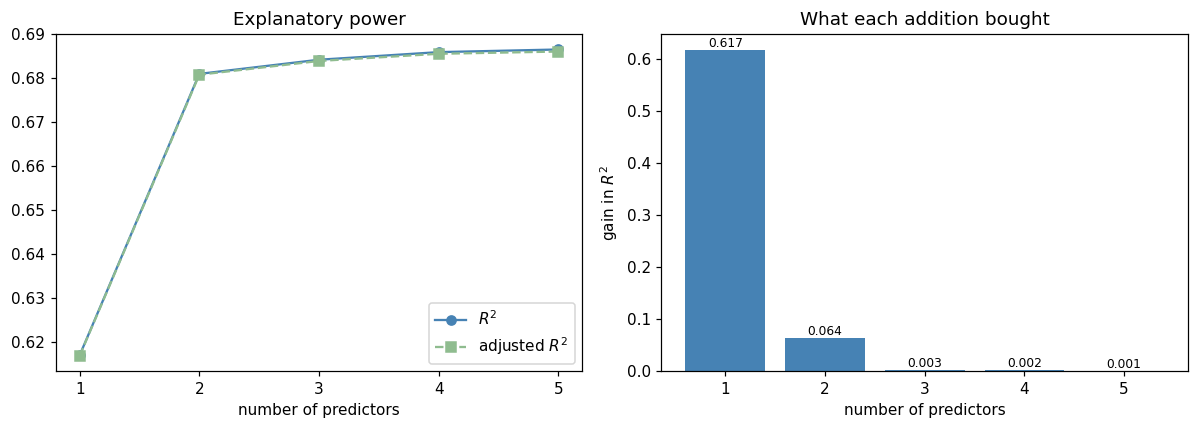

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(range(1, 6), build.R2, "o-", color="steelblue", label="$R^2$")
ax[0].plot(range(1, 6), build.adj_R2, "s--", color="darkseagreen", label="adjusted $R^2$")
ax[0].set(xlabel="number of predictors", ylabel="", title="Explanatory power", xticks=range(1, 6))
ax[0].legend()

ax[1].bar(range(1, 6), build.delta_R2, color="steelblue")
ax[1].set(xlabel="number of predictors", ylabel="gain in $R^2$",
          title="What each addition bought", xticks=range(1, 6))
for i, v in enumerate(build.delta_R2):
    ax[1].text(i + 1, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

The picture is stark. The first predictor delivers 0.617. The second adds 0.064. **The remaining three together add 0.005** — the bars are invisible next to the first two.

This shape — one or two dominant predictors and a long tail of statistically significant irrelevancies — is extremely common in real data, and it is why model building cannot be automated by $p$-values alone.

Note also that adjusted $R^2$ tracks $R^2$ closely here. That is expected: adjusted $R^2$ penalises each extra predictor by roughly $(1-R^2)/(n-k-1)$, which with $n = 3{,}361$ is a very light penalty. **Adjusted $R^2$ protects you against adding dozens of junk variables; it will not protect you against adding five plausible ones that do nothing.**

### 9.1 Where would a sensible person stop?

There is no formula for this. But three reasonable stopping rules, in increasing strictness:

1. **Stop when $p > 0.05$.** By this rule we keep all five, and would have kept all eight. At $n = 3{,}361$ this rule barely stops anything.
2. **Stop when adjusted $R^2$ stops rising.** Also keeps all five here — the penalty is too small to bite.
3. **Stop when the gain in $R^2$ falls below what you would care about** — say one percentage point. **This rule stops after two predictors**, and it is the one that matches how the model would actually be used.

For a payer trying to forecast the cost of a hospital stay, `LOS` and `NumRevCodes` are the model. The rest is decoration that happens to be statistically significant.

In [15]:
final = smf.ols("TotalCost ~ LOS + NumRevCodes", data=events).fit()
print(final.summary())

                            OLS Regression Results                            
Dep. Variable:              TotalCost   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     3584.
Date:                Fri, 31 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:35:57   Log-Likelihood:                -40316.
No. Observations:                3361   AIC:                         8.064e+04
Df Residuals:                    3358   BIC:                         8.066e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -1.451e+04   1318.958    -10.999      

---
## 10. Summary

| Step | Added | $t$ | $p$ | $R^2$ | gain |
|---|---|---|---|---|---|
| 1 | `LOS` | 73.6 | ~0 | 0.6170 | — |
| 2 | `NumRevCodes` | 25.9 | ~0 | 0.6810 | +0.0640 |
| 3 | `DiagnosisFreq` | −5.8 | 5e−09 | 0.6842 | +0.0032 |
| 4 | `HospitalVolume` | 4.3 | 2e−05 | 0.6859 | +0.0017 |
| 5 | `Age` | −2.5 | 0.011 | 0.6865 | +0.0006 |
| — | *rejected*: `AdmissionMonth`, `NumLines`, `PatientEvents` | all $p<0.01$ | | | all < +0.002 |

**What to take away.**

1. **$t$-tests and $R^2$ answer different questions.** Significance is about whether an effect exists; $R^2$ is about whether it matters. In a large sample the first is easy to achieve and the second is not.
2. **Coefficients depend on the company they keep.** `LOS` fell from \$11,305 to \$8,267 when service variety entered; `Age` reversed sign entirely.
3. **Statistical significance does not rescue a meaningless variable.** `AdmissionMonth` had $p < 0.01$ and was still nonsense in linear form.
4. **Screening correlations are a guide, not a decision.** `DiagnosisFreq` looked like noise at $r = 0.06$ and was highly significant; `NumLines` looked useful at $r = 0.43$ and was not.

### What we have not yet dealt with

Three problems are visible in the output of the final model and we have deliberately left all three alone.

- The **residuals are badly behaved** — the diagnostic statistics at the foot of the summary (Omnibus, Jarque–Bera, Kurtosis) are screaming. We will look at this properly next.
- Our rows are **not independent**: 3,361 events belong to only 1,757 patients.
- We have used only **linear forms of quantitative variables**. Cost is strictly positive and heavily skewed, which a straight line handles poorly, and we have ignored `TypeFlag` — the inpatient/emergency distinction — entirely.

**Next step:** residual diagnostics on this model, and what they tell us to do about it.